# <span style="color:red"> __AIFAKER__ </span>
[코드 깃허브](https://github.com/hyundairotemai2/AIFAKER/blob/main/AIFAKER.ipynb)

#### 모듈 모음

In [ ]:
!pip install scikit-image
!pip install torch
!pip install numpy
!pip install matplotlib
!pip install torchvision
!pip install tqdm
!pip install torch torchvision matplotlib numpy
!pip install torch torchvision diffusers transformers


## 노이즈 처리

__출력방식:__
- 원본 이미지, 노이즈 처리 이미지로 출력
- 노이즈 처리는 3단계로 구성됨 3%, 5%, 10% 순서
- 이미지 저장 이름은 다음과 같음 (원본명_모델명_노이즈(%).jpg)

#### 한글 출력 코드 (1번만 실행)

In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font():
    """한글 폰트 자동 설정"""
    font_candidates = ["NanumGothic", "Malgun Gothic", "AppleGothic"]  # Windows, Mac, Linux 폰트
    font_found = False

    for font in fm.findSystemFonts():
        font_name = fm.FontProperties(fname=font).get_name()
        if font_name in font_candidates:
            plt.rc("font", family=font_name)
            font_found = True
            print(f"✅ 한글 폰트 적용: {font_name}")
            break

    if not font_found:
        print("⚠️ 한글 폰트를 찾을 수 없습니다. 기본 폰트 사용.")

# 한글 폰트 설정 실행
set_korean_font()

✅ 한글 폰트 적용: Malgun Gothic


### StyleGAN

이미지 변환 및 저장 진행: 100%|██████████| 21/21 [01:04<00:00,  3.08s/it]


이미지 출력 중...


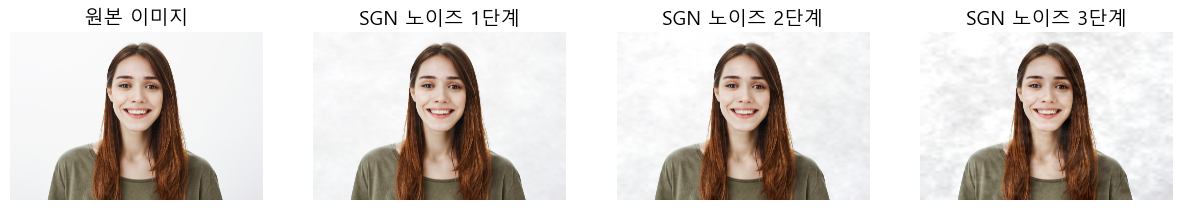

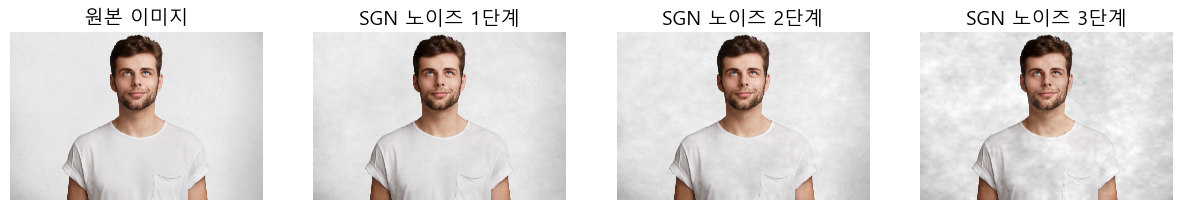

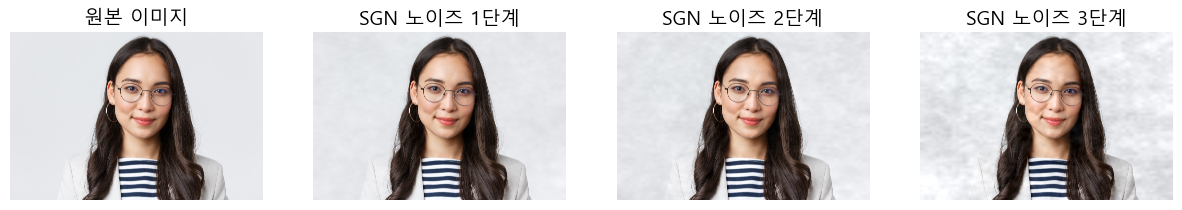

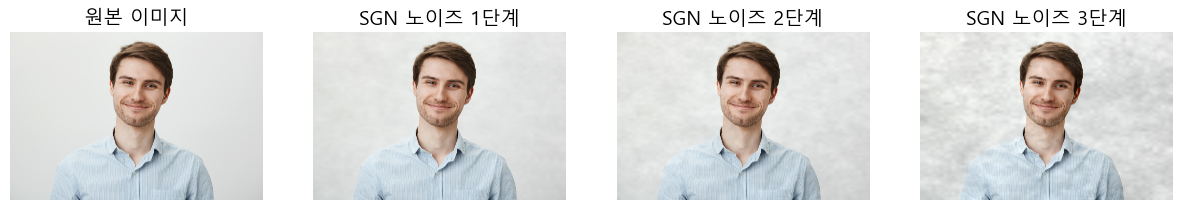

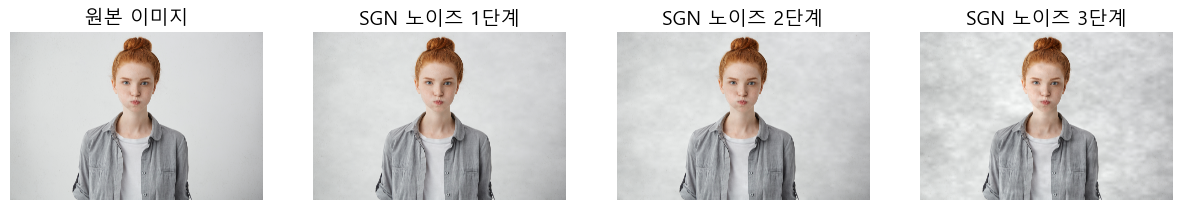

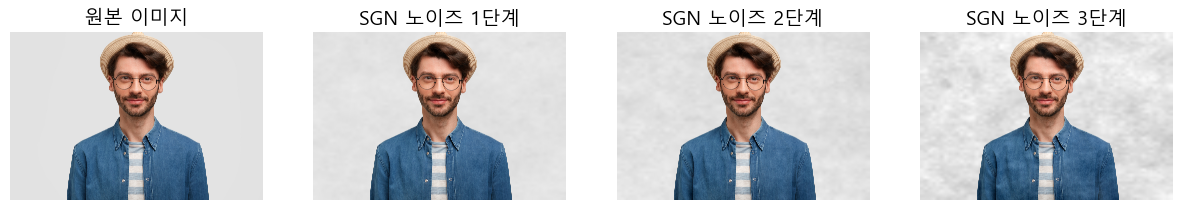

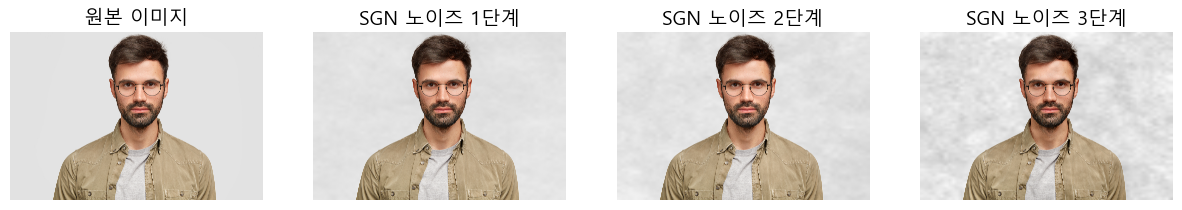

🎉 모든 SGN 보호 이미지 저장 완료!


In [17]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def generate_sgn_noise(image_tensor, strength=0.03):
    """스타일GAN 기반 보호 노이즈 생성"""
    noise_layers = []
    for scale in [4, 8, 16, 32, 64]:
        if scale <= image_tensor.shape[2] and scale <= image_tensor.shape[3]:
            noise = torch.randn(1, 1, scale, scale, device=image_tensor.device)
            upsampled = torch.nn.functional.interpolate(
                noise, size=(image_tensor.shape[2], image_tensor.shape[3]), mode='bilinear', align_corners=False
            )
            noise_layers.append(upsampled)
    
    combined_noise = sum(noise_layers) / len(noise_layers)
    noisy_image = image_tensor + combined_noise.expand_as(image_tensor) * strength
    return torch.clamp(noisy_image, 0, 1)

def protect_image(image_path, output_base, noise_level, model_name):
    """이미지에 스타일GAN 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")
    
    # 스타일GAN 기반 노이즈 적용
    noisy_img_tensor = generate_sgn_noise(img_tensor, noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())
    
    output_path = f"{output_base}_{model_name}_{int(noise_level*100)}.jpg"
    output_path = os.path.join(output_dir, os.path.basename(output_path))
    noisy_pil.save(output_path)
    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 노이즈 {i+1}단계", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.03, 0.05, 0.1), model_name="SGN"):
    """입력 폴더의 모든 이미지에 스타일GAN 보호 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="이미지 변환 및 저장 진행") as pbar:
        for img_path in image_paths:
            img_name, _ = os.path.splitext(os.path.basename(img_path))
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)
                os.makedirs(os.path.dirname(output_base), exist_ok=True)
                protected_pil = protect_image(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()

### Stable Diffusion Noise

Stable Diffusion 보호 변환 진행: 100%|██████████| 21/21 [01:17<00:00,  3.67s/it]


이미지 출력 중...


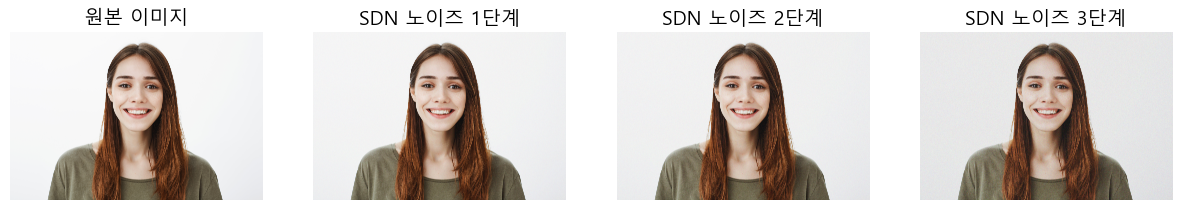

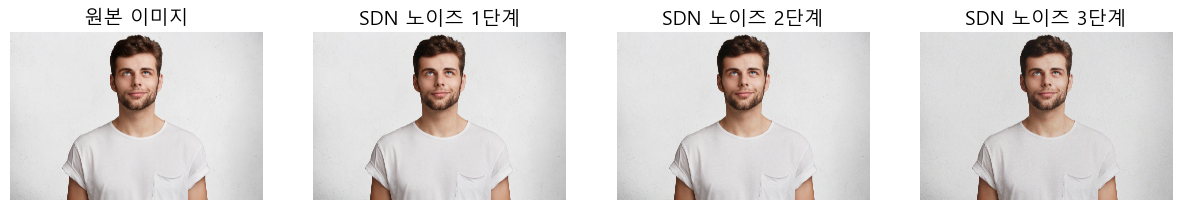

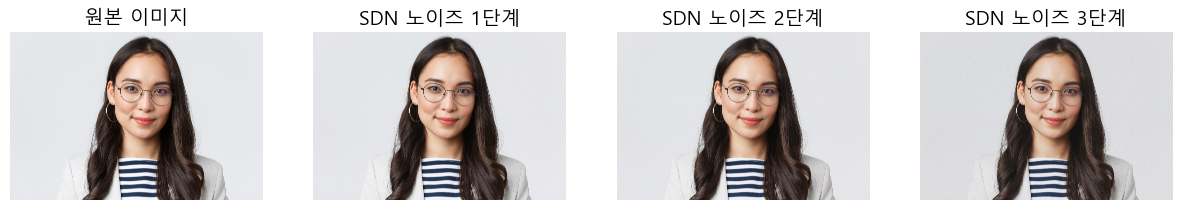

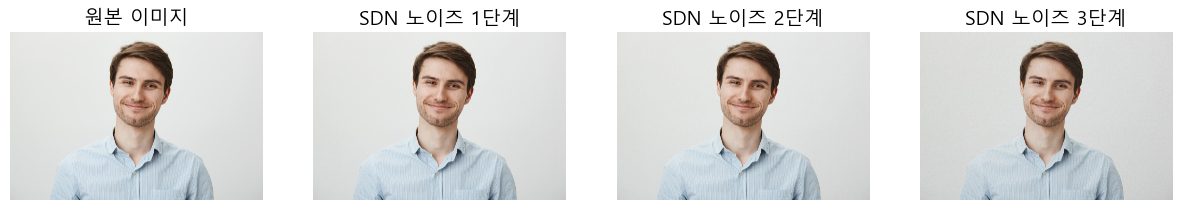

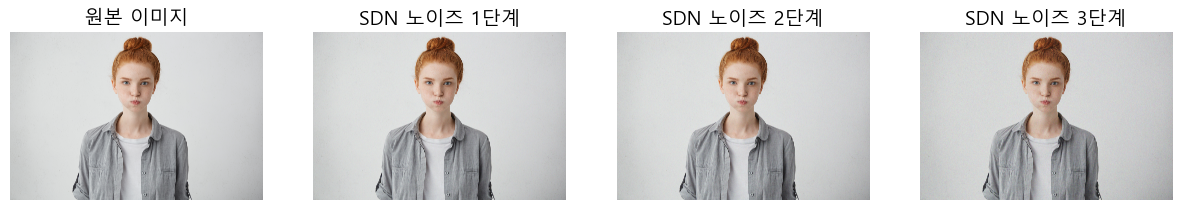

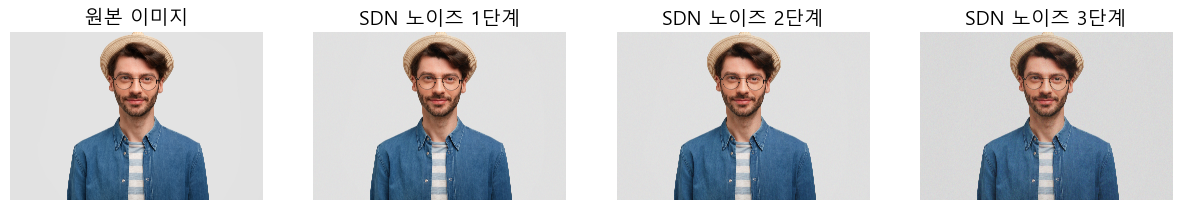

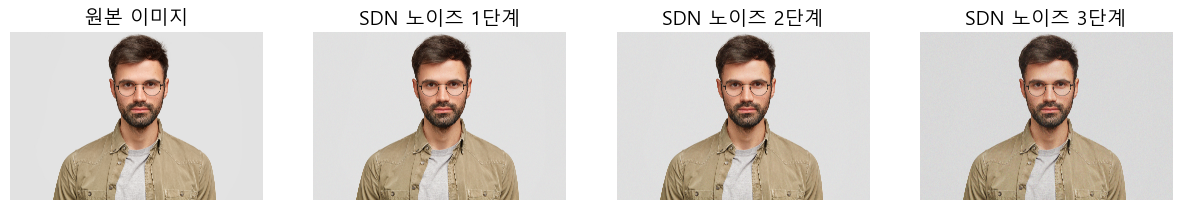

🎉 모든 SDN 보호 이미지 저장 완료!


In [18]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
from diffusers import DDPMScheduler

# 🔥 Stable Diffusion의 DDPMScheduler (Forward Diffusion 과정 사용)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02, beta_schedule="scaled_linear")

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def apply_stable_diffusion_noise(image_tensor, noise_level):
    """Stable Diffusion의 Forward Diffusion 과정에서 노이즈 추가"""
    timesteps = torch.tensor([int(noise_level * len(scheduler.timesteps))], dtype=torch.long).to(image_tensor.device)
    noise = torch.randn_like(image_tensor)
    noisy_image = scheduler.add_noise(image_tensor, noise, timesteps)
    return torch.clamp(noisy_image, 0, 1)

def protect_image(image_path, output_base, noise_level, model_name):
    """이미지에 Stable Diffusion 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    noisy_img_tensor = apply_stable_diffusion_noise(img_tensor, noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    # 원본 확장자 유지
    _, ext = os.path.splitext(image_path)  
    output_path = f"{output_base}_{model_name}_{int(noise_level*100)}{ext.lower()}"
    output_path = os.path.join(output_dir, os.path.basename(output_path))  # 최종 저장 경로

    noisy_pil.save(output_path)
    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 노이즈 {i+1}단계", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.03, 0.05, 0.1), model_name="SDN"):
    """입력 폴더의 모든 이미지에 Stable Diffusion 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="Stable Diffusion 보호 변환 진행") as pbar:
        for img_path in image_paths:
            img_name, ext = os.path.splitext(os.path.basename(img_path))  # 파일명 및 확장자 분리
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)  # 저장 경로 (확장자 제외)
                protected_pil = protect_image(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()

### Denoising Diffusion Probabilistic Models

DDPM 보호 변환 진행:   0%|          | 0/21 [00:00<?, ?it/s]

DDPM 보호 변환 진행: 100%|██████████| 21/21 [01:13<00:00,  3.51s/it]


이미지 출력 중...


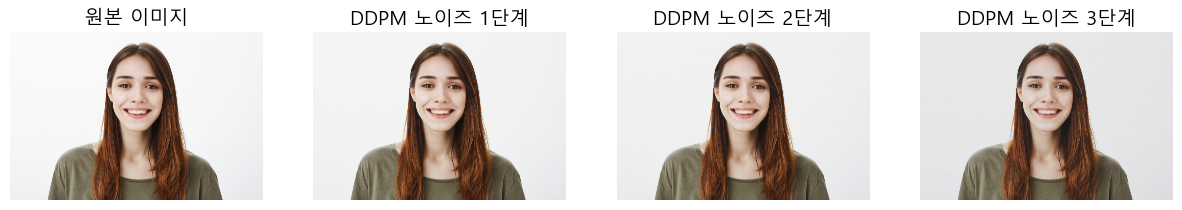

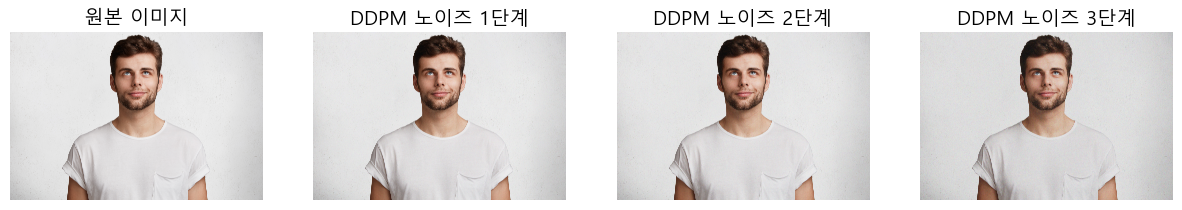

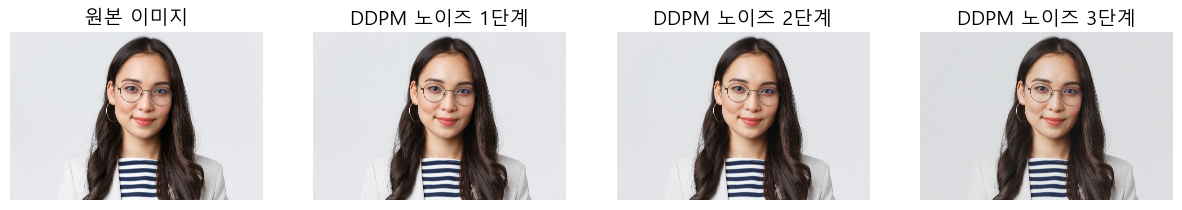

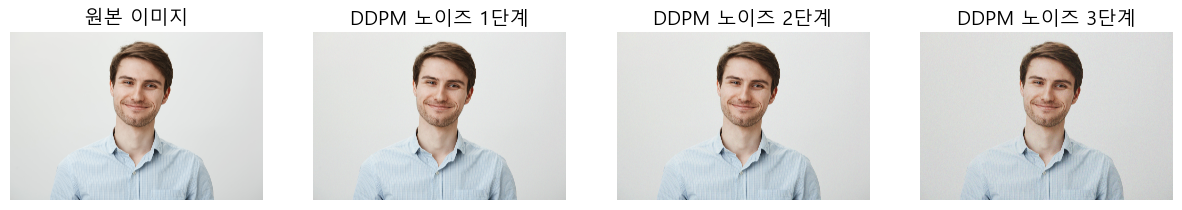

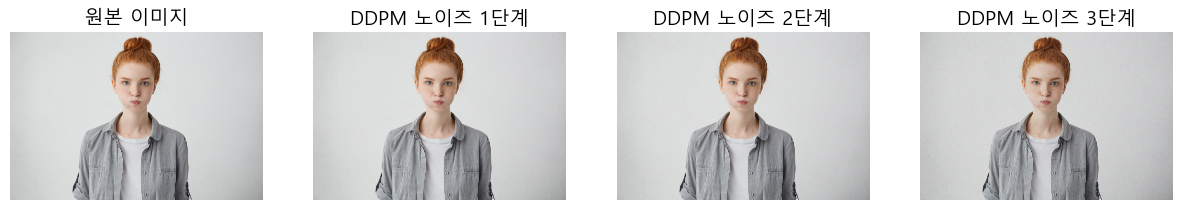

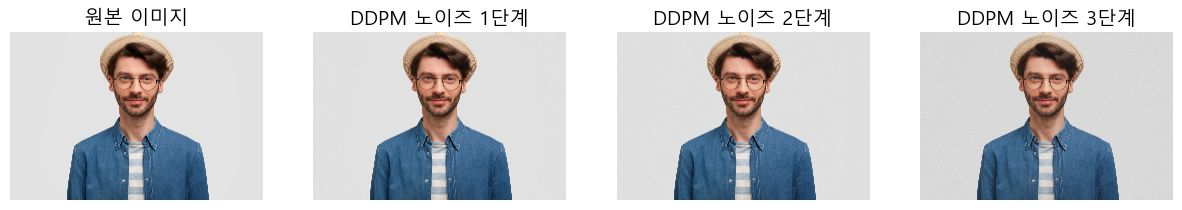

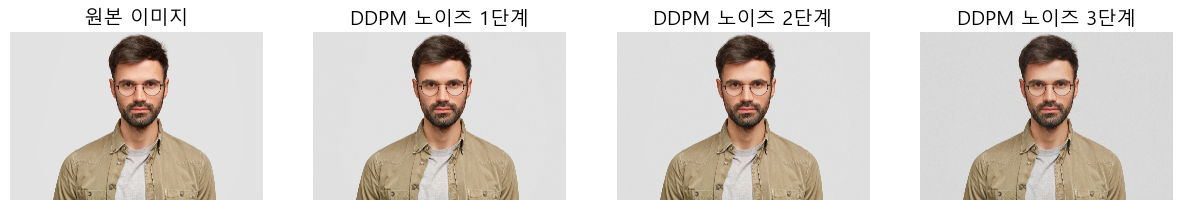

🎉 모든 DDPM 보호 이미지 저장 완료!


In [19]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
from diffusers import DDPMScheduler

# 🔥 DDPM 스케줄러 설정
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02, beta_schedule="scaled_linear")

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def apply_ddpm_noise(image_tensor, noise_level):
    """DDPM Forward Diffusion 방식으로 노이즈 추가"""
    timesteps = torch.tensor([int(noise_level * len(scheduler.timesteps))], dtype=torch.long).to(image_tensor.device)
    noise = torch.randn_like(image_tensor)
    noisy_image = scheduler.add_noise(image_tensor, noise, timesteps)
    return torch.clamp(noisy_image, 0, 1)

def protect_image(image_path, output_base, noise_level, model_name):
    """이미지에 DDPM 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    noisy_img_tensor = apply_ddpm_noise(img_tensor, noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    # 원본 확장자 유지
    _, ext = os.path.splitext(image_path)  
    output_path = f"{output_base}_{model_name}_{int(noise_level*100)}{ext.lower()}"
    output_path = os.path.join(output_dir, os.path.basename(output_path))  # 최종 저장 경로

    noisy_pil.save(output_path)
    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 노이즈 {i+1}단계", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.03, 0.05, 0.1), model_name="DDPM"):
    """입력 폴더의 모든 이미지에 DDPM 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="DDPM 보호 변환 진행") as pbar:
        for img_path in image_paths:
            img_name, ext = os.path.splitext(os.path.basename(img_path))  # 파일명 및 확장자 분리
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)  # 저장 경로 (확장자 제외)
                protected_pil = protect_image(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()

DDPM과 SDN 둘 다 같은 노이즈 추가 방식, 작동하는 공간과 세부 구현 방식에서 차이만 있으므로 둘 중 하나만 쓰는 걸로...

### Universal Adversarial Perturbations
FGSM(Fast Gradient Sign Method) 기반

UAP 보호 변환 진행: 100%|██████████| 21/21 [01:06<00:00,  3.18s/it]


이미지 출력 중...


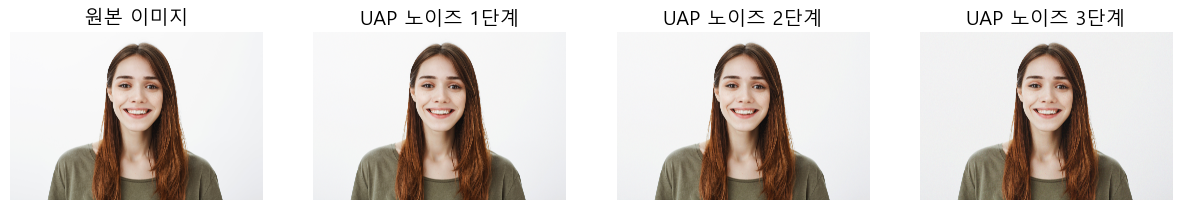

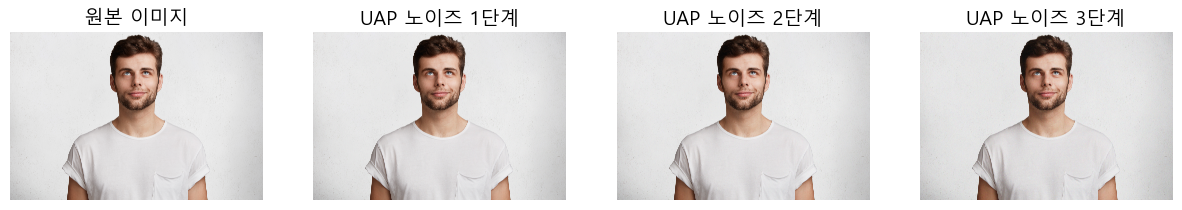

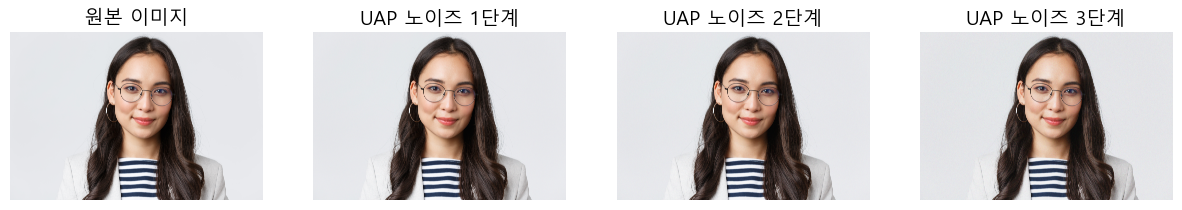

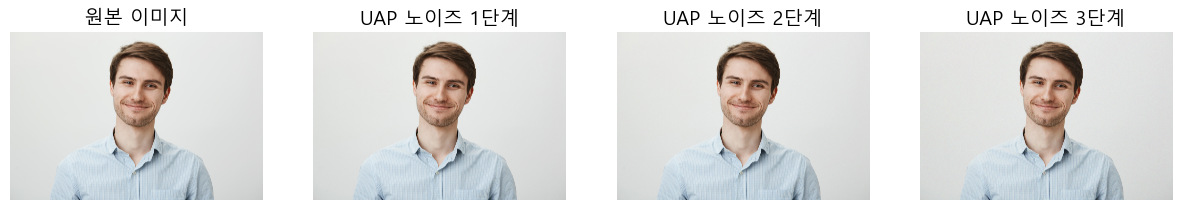

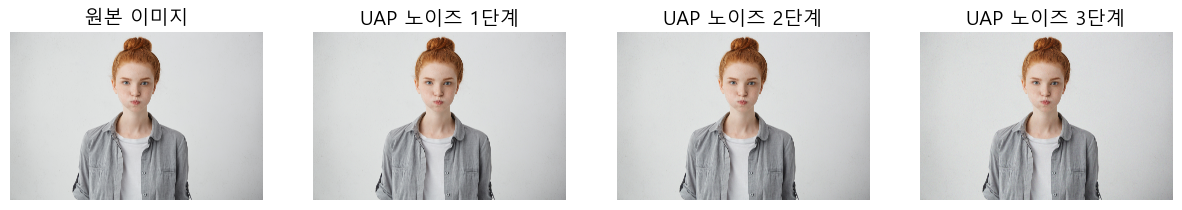

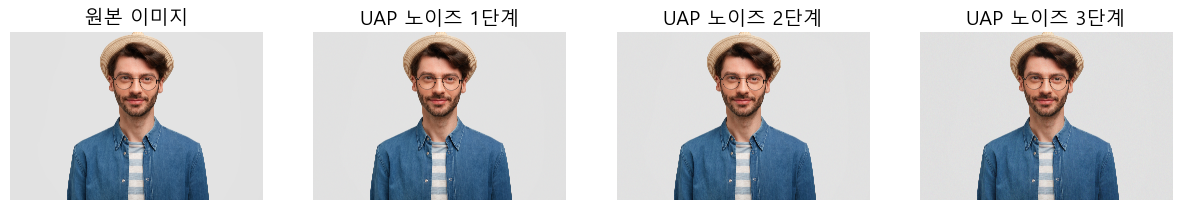

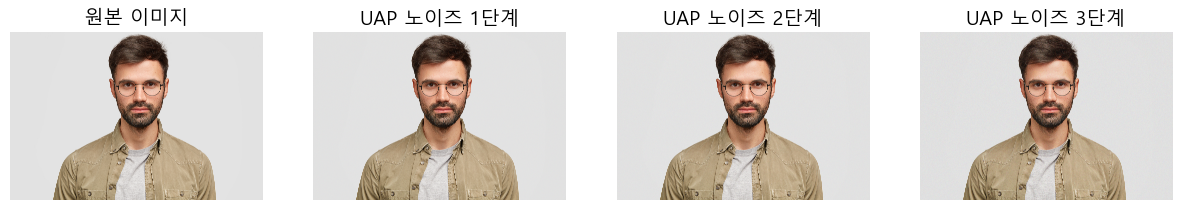

🎉 모든 UAP 보호 이미지 저장 완료!


In [20]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def generate_uap_noise(image_tensor, epsilon=0.03):
    """Universal Adversarial Perturbations(UAP) 방식으로 노이즈 추가"""
    noise = torch.randn_like(image_tensor) * epsilon  # 랜덤 노이즈 생성 및 크기 조정
    noisy_image = image_tensor + noise  # 원본 이미지에 노이즈 추가
    return torch.clamp(noisy_image, 0, 1)  # 값 범위 조정

def protect_image(image_path, output_base, noise_level, model_name):
    """이미지에 UAP 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    noisy_img_tensor = generate_uap_noise(img_tensor, epsilon=noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    # 원본 확장자 유지
    _, ext = os.path.splitext(image_path)
    output_path = f"{output_base}_{model_name}_{int(noise_level * 100)}{ext.lower()}"
    output_path = os.path.join(output_dir, os.path.basename(output_path))  # 최종 저장 경로

    noisy_pil.save(output_path)
    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 노이즈 {i+1}단계", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.03, 0.05, 0.1), model_name="UAP"):
    """입력 폴더의 모든 이미지에 UAP 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="UAP 보호 변환 진행") as pbar:
        for img_path in image_paths:
            img_name, ext = os.path.splitext(os.path.basename(img_path))  # 파일명 및 확장자 분리
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)  # 저장 경로 (확장자 제외)
                protected_pil = protect_image(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()

## 검증

### PSNR (Peak Signal-to-Noise Ratio) & SSIM (Structural Similarity) 계산

__목표:__

- PSNR (신호 대 잡음비): 원본과 변형된 이미지의 유사도 측정 (값이 클수록 원본과 유사)
- SSIM (구조적 유사도): 이미지의 구조적 차이를 정량화 (값이 1에 가까울수록 원본과 유사)
검증 방법:

- PSNR이 낮으면 노이즈가 강하게 적용된 것
- SSIM이 낮으면 원본과 구조적으로 차이가 많아진 것

In [21]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

def calculate_psnr_ssim(original, noisy):
    """PSNR 및 SSIM 계산"""
    original = np.array(original.convert("L"))  # 흑백 변환
    noisy = np.array(noisy.convert("L"))  # 흑백 변환

    # PSNR 계산
    mse = np.mean((original - noisy) ** 2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

    # SSIM 계산
    ssim_value = ssim(original, noisy, data_range=noisy.max() - noisy.min())

    return psnr, ssim_value

def validate_output(original, protected_list):
    """각 보호된 이미지에 대해 PSNR 및 SSIM 평가"""
    for i, protected in enumerate(protected_list):
        psnr, ssim_value = calculate_psnr_ssim(original, protected)
        print(f"🔹 노이즈 단계 {i+1}: PSNR={psnr:.2f}, SSIM={ssim_value:.4f}")

### Robustness Test

__목표:__

- 원본 이미지와 노이즈 이미지가 AI 모델에서 같은 클래스로 예측되는지 확인
- 이미지 분류 모델 (ResNet, EfficientNet) 등을 사용해 비교

__검증 방법:__

- Pre-trained 모델 (ResNet50 등) 사용
- 원본 vs. 노이즈 이미지 각각 예측
- 노이즈 강도가 올라갈수록 예측 정확도가 낮아지는지 확인

In [22]:
import torch
import torchvision.models as models
import torchvision.transforms as T

# Pre-trained ResNet 모델 로드 (최신 방식 적용)
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()

def predict_image(image):
    """이미지를 ResNet 모델을 사용하여 분류"""
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0)  # 배치 차원 추가
    image_tensor = image_tensor.to("cuda" if torch.cuda.is_available() else "cpu")  # GPU 사용 가능하면 GPU로 이동

    model.to(image_tensor.device)  # 모델을 입력 이미지와 같은 디바이스로 이동

    with torch.no_grad():
        output = model(image_tensor)

    return torch.argmax(output).item()

def evaluate_model_robustness(original, protected_list):
    """원본 및 보호된 이미지의 분류 결과 비교"""
    original_label = predict_image(original)
    print(f"🖼️ 원본 이미지 예측 라벨: {original_label}")

    for i, protected in enumerate(protected_list):
        noisy_label = predict_image(protected)
        print(f"🔹 노이즈 {i+1}단계 예측 라벨: {noisy_label}")

### 통합 검증 모델

##### __출력 방식__
1. 원본 이미지 검증 수치
2. 원본 이미지
3. 모델
4. 노이즈 처리 이미지
5. 노이즈 검증 수치
6. 모델 끝나면 3번부터 다시 다른 모델 검증 진행
7. 모든 모델 검증 후 다음 이미지 검증

In [23]:
import os
import glob
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric
from IPython.display import display, HTML, clear_output
import torchvision.models as models

# ✅ ResNet50 모델 로드
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ✅ ImageNet 클래스 라벨 로드
imagenet_classes = {idx: label for (idx, label) in enumerate(models.ResNet50_Weights.DEFAULT.meta["categories"])}
human_classes = {"person", "man", "woman", "boy", "girl", "bust"}

def calculate_psnr_ssim(original, noisy):
    """PSNR 및 SSIM 값 계산"""
    original = np.array(original)
    noisy = np.array(noisy)
    psnr_value = psnr_metric(original, noisy, data_range=255)
    win_size = min(7, min(original.shape[:2]))  # 최소 7 또는 이미지 크기
    ssim_value = ssim_metric(original, noisy, win_size=win_size, channel_axis=-1)
    return psnr_value, ssim_value

def predict_image(image):
    """ResNet50 Pretrained 모델로 사람으로 인식될 확률 (%) 계산"""
    image_tensor = transform(image).unsqueeze(0)
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

    human_prob = sum(probabilities[idx].item() for idx, label in imagenet_classes.items() if any(h in label for h in human_classes))
    return f"{human_prob * 100:.2f}%"  # 확률(%)

def generate_image_html(image_path, width=150):
    """이미지를 HTML 태그로 변환"""
    return f'<img src="{image_path}" width="{width}">'

def validate_images(input_dir="./Output/"):
    """모든 이미지에 대해 PSNR, SSIM, AI 모델 예측 수행 및 테이블 출력"""
    image_dict = {}
    image_paths = glob.glob(os.path.join(input_dir, "*_*_*.jpg"))

    # 모든 이미지 파일 분류
    for img_path in image_paths:
        img_name, ext = os.path.splitext(os.path.basename(img_path))
        parts = img_name.split("_")
        if len(parts) < 3:
            continue
        base_name = "_".join(parts[:-2])
        model_name = parts[-2]
        try:
            noise_level = int(parts[-1])
        except ValueError:
            continue

        if base_name not in image_dict:
            image_dict[base_name] = {}
        if model_name not in image_dict[base_name]:
            image_dict[base_name][model_name] = {}

        image_dict[base_name][model_name][noise_level] = img_path

    # 총 작업량 계산 (모든 이미지 파일 수)
    total_work = sum(sum(len(noise_dict) for noise_dict in models.values()) for models in image_dict.values())

    # ✅ 진행 바 추가
    progress_bar = tqdm(total=total_work, desc="이미지 검증 진행")

    results_dict = {}

    for base_name, models in image_dict.items():
        original_img_path = f"./Input/{base_name}.jpg"
        original_img_html = generate_image_html(original_img_path)  # ✅ 개별 원본 이미지 저장

        results_dict[base_name] = {}

        for model_name, noise_dict in models.items():
            sorted_noise_levels = sorted(noise_dict.keys())
            noise_results = []

            for noise_level in sorted_noise_levels:
                noisy_img_path = noise_dict.get(noise_level, None)
                if noisy_img_path is None:
                    continue

                noisy_img = Image.open(noisy_img_path).convert("RGB")
                psnr, ssim_value = calculate_psnr_ssim(Image.open(original_img_path), noisy_img)
                ai_label = predict_image(noisy_img)
                noisy_img_html = generate_image_html(noisy_img_path)

                noise_results.append((noisy_img_html, psnr, ssim_value, ai_label))

                # ✅ 진행 바 업데이트
                progress_bar.update(1)

            results_dict[base_name][model_name] = noise_results

    progress_bar.close()

    # ✅ 진행 바 제거 후 테이블 준비 중 메시지 표시
    clear_output(wait=True)
    print("\n📊 테이블 준비 중...")

    # ✅ 최대 노이즈 단계 계산
    max_noise_levels = max((len(noise_results) for models in results_dict.values() for noise_results in models.values()), default=0)

    columns = ["원본 이미지", "모델"] + [f"노이즈 단계 {i+1}" for i in range(max_noise_levels)]

    table_data = []

    for base_name, models in results_dict.items():
        original_img_path = f"./Input/{base_name}.jpg"
        original_img_html = generate_image_html(original_img_path)

        for model_name, noise_results in models.items():
            # 각 모델의 첫 번째 행(이미지 행)에 원본 이미지 표시
            row_model = [original_img_html, model_name]
            row_ai = ["", "사람 확률 (%)"]
            row_psnr = ["", "PSNR"]
            row_ssim = ["", "SSIM"]

            for noisy_img_html, psnr, ssim_value, ai_label in noise_results:
                row_model.append(noisy_img_html)
                row_ai.append(ai_label)
                row_psnr.append(f"{psnr:.2f}")
                row_ssim.append(f"{ssim_value:.4f}")

            table_data.append(row_model)
            table_data.append(row_ai)
            table_data.append(row_psnr)
            table_data.append(row_ssim)

    df_results = pd.DataFrame(table_data, columns=columns)

    # ✅ 테이블 출력 전 메시지 제거
    clear_output(wait=True)

    # ✅ 테이블 출력
    display(HTML(df_results.to_html(escape=False, index=False)))

    # ✅ 검증 완료 메시지
    print("\n✅ 검증 완료! 모든 결과가 출력되었습니다.")

# 실행
validate_images()

원본 이미지,모델,노이즈 단계 1,노이즈 단계 2,노이즈 단계 3
,DDPM,,,
,사람 확률 (%),0.69%,0.69%,0.73%
,PSNR,28.14,24.48,19.24
,SSIM,0.4944,0.3115,0.1293
,SDN,,,
,사람 확률 (%),0.68%,0.67%,0.70%
,PSNR,28.14,24.48,19.24
,SSIM,0.4941,0.3114,0.1293
,SGN,,,
,사람 확률 (%),0.80%,0.78%,0.72%



✅ 검증 완료! 모든 결과가 출력되었습니다.
